In [3]:
import matplotlib.pyplot as plt

from srm import run_bcsd
from srm.downscaling_utils import splice_scenarios

In [4]:
dict_all = run_bcsd.get_all_data(gcm="CESM2-WACCM", var_name="rsds", verbose=True)

Loaded data: 1.41 seconds


# Process data

In [5]:
sai = dict_all["model_sai"]
ssp = dict_all["model_scenario"]
hist = dict_all["model_hist"]

tseries_ssp = splice_scenarios(hist, ssp, scenario1_end_year=2014)
tseries_sai = splice_scenarios(tseries_ssp, sai, scenario1_end_year=2034)
tseries_sai = tseries_sai.where(tseries_sai["time.year"] < 2085, drop=True)
tseries_ssp = tseries_ssp.where(tseries_ssp["time.year"] < 2085, drop=True)

tseries_ssp_annual = tseries_ssp.groupby("time.year").mean()
tseries_sai_annual = tseries_sai.groupby("time.year").mean()

In [6]:
hovmoller_ssp = tseries_ssp_annual.mean(dim="lon").compute()
hovmoller_sai = tseries_sai_annual.mean(dim="lon").compute()

In [7]:
baseline = hovmoller_ssp.sel(year=slice(1978, 2000)).mean(dim="year")

In [8]:
hovmoller_delta_ssp = hovmoller_ssp - baseline
hovmoller_delta_sai = hovmoller_sai - baseline

# Figures comparing SSP245 and SAI scenario (G6-1.5K) over time and during 2035-2085

### Hovmoller diagram (changes over time by latitude)

Text(0.5, 1.0, 'SAI')

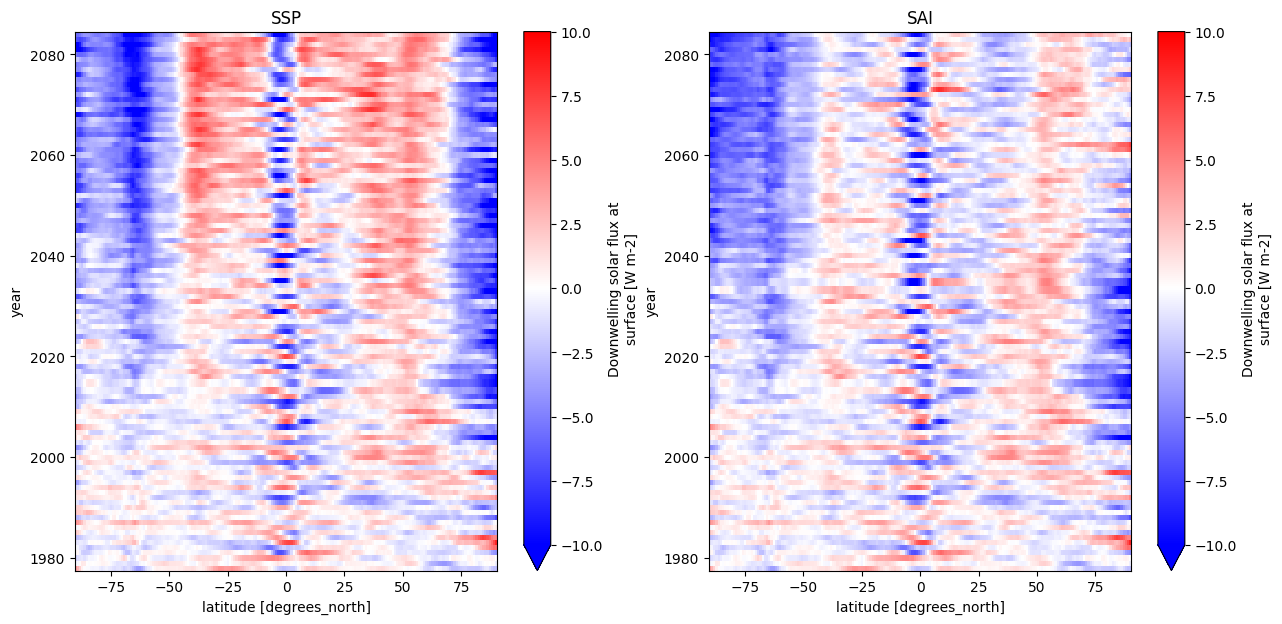

In [8]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
hovmoller_delta_ssp.plot(x="lat", y="year", cmap="bwr", vmax=10, vmin=-10)
plt.title("SSP")
plt.subplot(1, 2, 2)
hovmoller_delta_sai.plot(x="lat", y="year", cmap="bwr", vmax=10, vmin=-10)
plt.title("SAI")

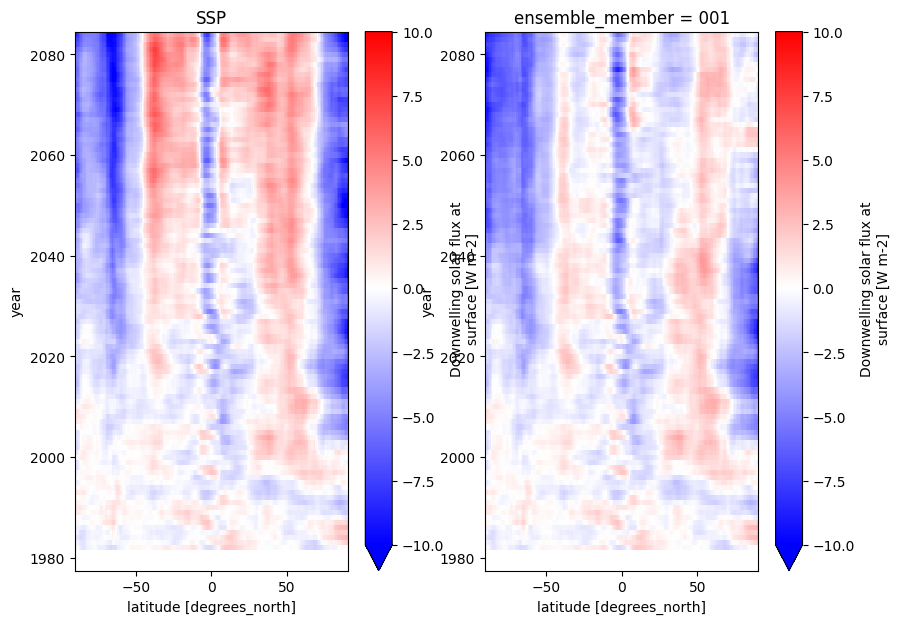

In [14]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 3, 1)
hovmoller_delta_ssp.rolling(year=5).mean().plot(x="lat", y="year", cmap="bwr", vmax=10, vmin=-10)
plt.title("SSP")
plt.subplot(1, 3, 2)
hovmoller_delta_sai.rolling(year=5).mean().plot(x="lat", y="year", cmap="bwr", vmax=10, vmin=-10)

### Zonal mean of 2035-2085 relative to 1978-2000 baseline period

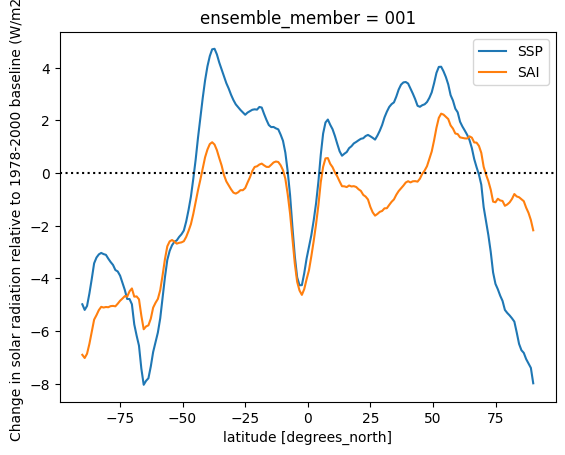

In [10]:
hovmoller_delta_ssp.sel(year=slice(2035, 2084)).mean(dim="year").plot(label="SSP")
hovmoller_delta_sai.sel(year=slice(2035, 2084)).mean(dim="year").plot(label="SAI")
plt.axhline(y=0, linestyle=":", color="k")
plt.ylabel("Change in solar radiation relative to 1978-2000 baseline (W/m2)")
plt.legend()

### Maps 2035-2085 relative to 1978-2000 baseline period

In [16]:
ssp_mean = tseries_ssp_annual.sel(year=slice(2035, 2084)).mean(dim="year").compute()
sai_mean = tseries_sai_annual.sel(year=slice(2035, 2084)).mean(dim="year").compute()
baseline_mean = tseries_ssp_annual.sel(year=slice(1978, 2000)).mean(dim="year").compute()

Text(0.5, 1.0, 'SAI-SSP')

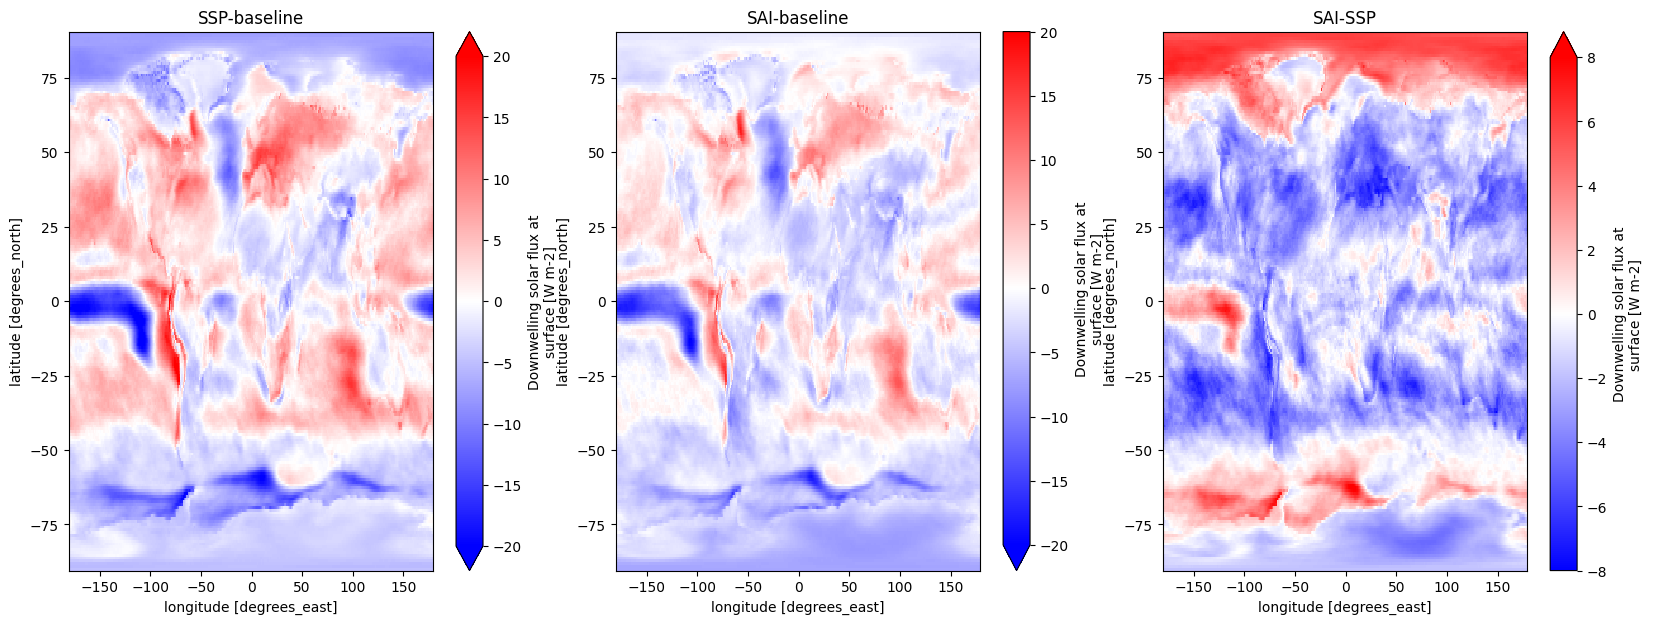

In [27]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 3, 1)
(ssp_mean - baseline_mean).plot(cmap=plt.cm.bwr, vmax=20)
plt.title("SSP-baseline")
plt.subplot(1, 3, 2)
(sai_mean - baseline_mean).plot(cmap=plt.cm.bwr, vmax=20)
plt.title("SAI-baseline")
plt.subplot(1, 3, 3)
(sai_mean - ssp_mean).plot(cmap=plt.cm.bwr, vmax=8)
plt.title("SAI-SSP")